In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import shap # Libreria fondamentale per l'interpretabilità (Punto Bonus)

In [9]:
# ---------------------------------------------------------
# 1. CARICAMENTO DEI DATI
# ---------------------------------------------------------
# Assumiamo che il file sia nella stessa cartella dello script
file_path = 'credit_scoring.csv'
print("Caricamento dataset in corso...")

try:
    df = pd.read_csv(file_path)
    print(f"Dataset caricato con successo: {df.shape[0]} righe, {df.shape[1]} colonne.")
except FileNotFoundError:
    print("Errore: Il file 'credit_scoring.csv' non è stato trovato.")

Caricamento dataset in corso...
Dataset caricato con successo: 338427 righe, 19 colonne.


In [10]:
# ---------------------------------------------------------
# 2. DATA CLEANING E FEATURE ENGINEERING
# ---------------------------------------------------------
if not df.empty:
    print("\nAvvio pulizia e trasformazione dati...")

    # Rimuoviamo l'ID perché non ha valore predittivo
    if 'ID' in df.columns:
        df = df.drop('ID', axis=1)

    # --- Trasformazione Età ---
    # DAYS_BIRTH è negativo (giorni indietro). Lo convertiamo in anni positivi.
    df['AGE_YEARS'] = abs(df['DAYS_BIRTH']) / 365
    df = df.drop('DAYS_BIRTH', axis=1) # Rimuoviamo la colonna originale

    # --- Trasformazione Anzianità Lavorativa ---
    # DAYS_EMPLOYED: valori positivi indicano disoccupazione/pensione.
    # Creiamo una flag per "Disoccupato" e convertiamo il resto in anni.
    df['UNEMPLOYED'] = (df['DAYS_EMPLOYED'] > 0).astype(int)
    
    # Se > 0 mettiamo 0 anni di esperienza, altrimenti convertiamo i giorni negativi in anni positivi
    df['YEARS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: 0 if x > 0 else abs(x)/365)
    df = df.drop('DAYS_EMPLOYED', axis=1)

    # --- Gestione Valori Mancanti ---
    # OCCUPATION_TYPE ha spesso valori nulli. Li riempiamo con 'Other'
    if 'OCCUPATION_TYPE' in df.columns:
        df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Other')

    # --- Encoding Variabili Categoriche ---
    # Trasformiamo tutte le colonne di testo (object) in numeri tramite One-Hot Encoding
    # drop_first=True serve a evitare la collinearità (es. se non è maschio è femmina)
    categorical_cols = df.select_dtypes(include=['object']).columns
    df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

    print("Data cleaning completato.")


Avvio pulizia e trasformazione dati...
Data cleaning completato.


In [11]:
# ---------------------------------------------------------
    # 3. PREPARAZIONE PER IL MODELLO
    # ---------------------------------------------------------
X = df_encoded.drop('TARGET', axis=1) # Features
y = df_encoded['TARGET']              # Variabile da prevedere

    # Divisione in Train (80%) e Test (20%)
    # stratify=y assicura che la proporzione di buoni/cattivi pagatori sia la stessa in train e test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [12]:
# ---------------------------------------------------------
    # 4. ADDESTRAMENTO MODELLO (Random Forest)
    # ---------------------------------------------------------
print("\nAddestramento del modello Random Forest in corso...")
    
    # class_weight='balanced' è CRUCIALE se i dati sono sbilanciati (pochi cattivi pagatori)
model = RandomForestClassifier(n_estimators=100, 
                                   random_state=42, 
                                   class_weight='balanced',
                                   max_depth=10) # Limitiamo la profondità per evitare overfitting
model.fit(X_train, y_train)


Addestramento del modello Random Forest in corso...


RandomForestClassifier(class_weight='balanced', max_depth=10, random_state=42)

In [13]:
# ---------------------------------------------------------
    # 5. VALUTAZIONE DELLE PERFORMANCE
    # ---------------------------------------------------------
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1] # Probabilità di essere classe 1

print("\n--- REPORT PERFORMANCE ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
print("\nMatrice di Confusione:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


--- REPORT PERFORMANCE ---
Accuracy: 0.9509
ROC-AUC Score: 0.9777

Matrice di Confusione:
[[58474  3268]
 [   58  5886]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.97     61742
           1       0.64      0.99      0.78      5944

    accuracy                           0.95     67686
   macro avg       0.82      0.97      0.88     67686
weighted avg       0.97      0.95      0.96     67686




--- ANALISI INTERPRETABILITÀ (SHAP) ---
Calcolo dei valori SHAP per spiegare le decisioni...

Generazione Summary Plot...


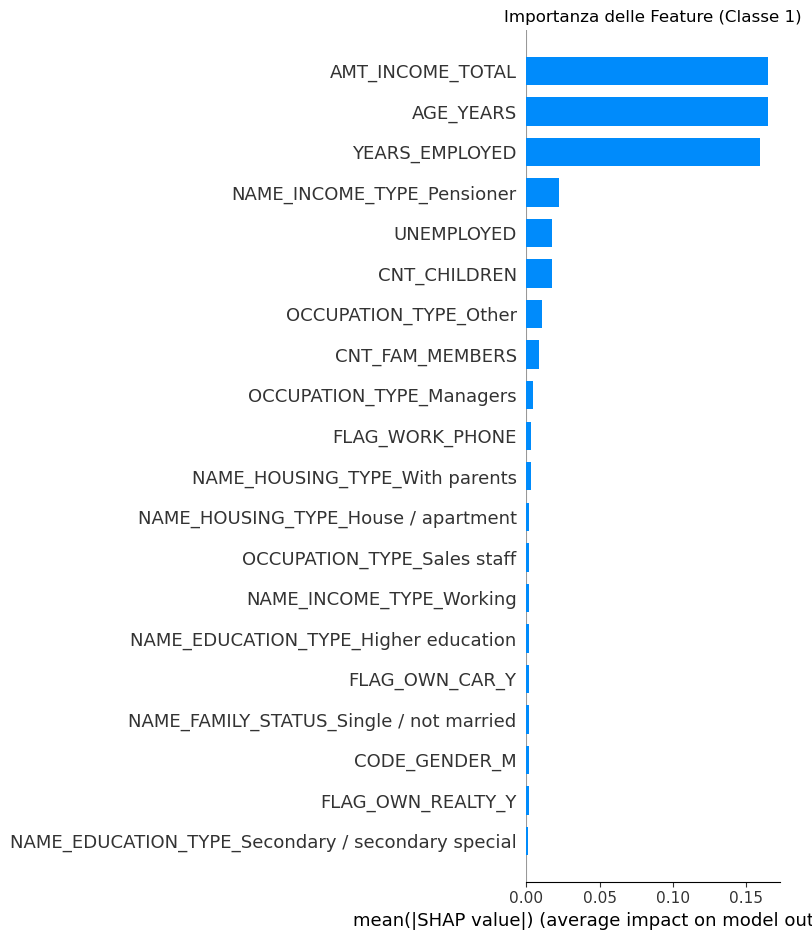


Analisi per il cliente 0...
Predizione reale modello: 0 (0=Rifiutato, 1=Accettato)


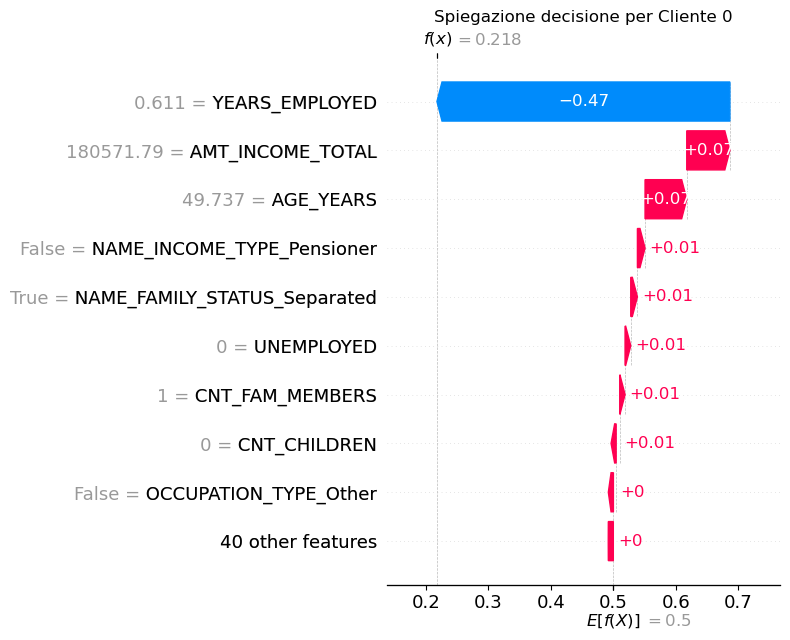

In [15]:
# ---------------------------------------------------------
# 6. PUNTO BONUS: INTERPRETABILITÀ CON SHAP
# ---------------------------------------------------------
print("\n--- ANALISI INTERPRETABILITÀ (SHAP) ---")
print("Calcolo dei valori SHAP per spiegare le decisioni...")

# 1. Creiamo l'explainer
explainer = shap.TreeExplainer(model)

# 2. Calcoliamo l'oggetto Explanation (NUOVA API, più stabile)
# Questo oggetto contiene tutto: valori shap, dati base e dati osservati
shap_explanation = explainer(X_test)

# 3. Gestione delle dimensioni per Classificazione Binaria
# shap_explanation ha dimensione (n_samples, n_features, n_classes)
# A noi interessa la classe 1 (Buon Pagatore/Successo) per capire cosa guida il "Sì" o il "No"
# Selezioniamo tutte le righe, tutte le colonne, e l'indice 1 della classe
shap_values_class1 = shap_explanation[:, :, 1]

# --- GRAFICO GLOBALE (Summary Plot) ---
print("\nGenerazione Summary Plot...")
plt.figure()
# Qui passiamo shap_values_class1 che ora ha la forma corretta
shap.summary_plot(shap_values_class1, X_test, plot_type="bar", show=False)
plt.title("Importanza delle Feature (Classe 1)")
plt.tight_layout()
plt.show()

# --- GRAFICO SINGOLO CLIENTE (Waterfall Plot) ---
# Scegliamo un cliente (es. indice 0)
customer_idx = 0 

print(f"\nAnalisi per il cliente {customer_idx}...")
print(f"Predizione reale modello: {y_pred[customer_idx]} (0=Rifiutato, 1=Accettato)")

plt.figure()
# Passiamo l'oggetto explanation specifico di quel cliente
shap.plots.waterfall(shap_values_class1[customer_idx], show=False)
plt.title(f"Spiegazione decisione per Cliente {customer_idx}")
plt.tight_layout()
plt.show()